# Monocyte-count benchmark, supplementary tables, and representative UMAP

This notebook reproduces the monocyte simulation benchmark and writes manuscript-ready CSV files to:

- `nature_genetics_supplementary_monocyte/`
- `nature_genetics_supplementary_monocyte_csvs.zip`

The supplementary exports include:

- one row per **method × causal-cell proportion × replicate** with empirical FDR/FDP, power, AUPRC, average precision, AUROC, discovery counts, confusion-matrix counts, and additional diagnostic metrics;
- separate per-replicate CSVs for empirical FDR, power, AUPRC, average precision, AUROC, and other useful metrics;
- mean, SD, SEM, 95% CI, median, IQR, range, and replicate count by method and simulation setting;
- paired per-replicate differences comparing scDRS-FM with scDRS and scPagwas;
- exact and collapsed cell-population counts for the large reference `.h5ad` file;
- per-replicate cell-population counts and causal-cell fractions for each simulated `.h5ad` file;
- a data-availability table documenting missing or unusable inputs instead of silently dropping runs;
- a CSV manifest and a zip archive containing all generated CSVs.

The benchmark compares **scDRS-FM**, **scDRS**, and **scPagwas**. Run the notebook from the project root, or set `PROJECT_ROOT` below.

scPagwas remains optional. If its reference `.h5ad` or a score file is unavailable, the notebook records that status and continues with the available methods.


In [1]:
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
import warnings
import zipfile

import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)
from statsmodels.stats.multitest import multipletests


In [2]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
PROJECT_ROOT = Path(".")
TRAIT_PREFIX = "UKB_460K.blood_MONOCYTE_COUNT"
BIOCLASSIFICATION_KEY = "BioClassification"
FDR_ALPHA = 0.10
P_VALUE_FLOOR = 1e-300

# Manuscript supplementary outputs.
SUPPLEMENTARY_OUTPUT_DIR = PROJECT_ROOT / "nature_genetics_supplementary_monocyte"
SUPPLEMENTARY_ZIP_OUTPUT = PROJECT_ROOT / "nature_genetics_supplementary_monocyte_csvs.zip"
SUPPLEMENTARY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Benchmark configuration.
PROPS = ["100_300", "150_300", "200_300", "250_300", "300_300"]
PROP_TICK_LABELS = {
    "100_300": "7%",
    "150_300": "10%",
    "200_300": "13%",
    "250_300": "15%",
    "300_300": "18%",
}
N_REPLICATES = 30
CAUSAL_CELL_TYPES = ["13_CD16.Mono", "12_CD14.Mono.2", "11_CD14.Mono.1"]
BENCHMARK_OUTPUT = PROJECT_ROOT / "Monocyte_Count_all_metrics_row.png"

METHOD_LABELS = {
    "scdrs_fm": "scDRS-FM",
    "scdrs": "scDRS",
    "scpagwas": "scPagwas",
}

# Metrics written as separate per-replicate tables. Empirical FDR is the
# realized false-discovery proportion (FDP) in each simulation replicate.
PER_REPLICATE_EXPORT_METRICS = [
    "empirical_fdr",
    "power",
    "auprc",
    "average_precision",
    "auroc",
    "precision",
    "specificity",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "balanced_accuracy",
    "mcc",
    "discovery_rate",
    "auprc_lift_over_prevalence",
]

# Representative UMAP configuration.
PROP = "300_300"
REPLICATE = 1
RANDOM_SEED = 1
COLOR_VMAX = 4.0
UMAP_OUTPUT = PROJECT_ROOT / f"umap_{PROP}_rep{REPLICATE}_2x2.png"

# The large reference h5ad is used both for scPagwas labels and for the
# manuscript cell-population inventory requested below.
SCPAGWAS_REFERENCE_H5AD = (
    PROJECT_ROOT / "scpagwas" / "Seu_Healthy_Hema_RAW.h5ad"
)
BIG_H5AD_PATH = SCPAGWAS_REFERENCE_H5AD

# Friendly labels used only for collapsed summaries and plotting. The exact
# BioClassification labels are always retained in the primary count table.
BIO_TO_CELLTYPE = {
    "06_CLP.1": "CLP",
    "15_CLP.2": "CLP",
    "08_GMP.Neut": "GMP/Neut progenitor",
    "09_pDC": "pDC",
    "10_cDC": "cDC",
    "16_Pre.B": "Pre-B",
    "17_B": "B cell",
    "20_CD4.N1": "CD4 naïve",
    "21_CD4.N2": "CD4 naïve",
    "22_CD4.M": "CD4 memory",
    "19_CD8.N": "CD8 naïve",
    "23_CD8.EM": "CD8 effector memory",
    "24_CD8.CM": "CD8 central memory",
    "25_NK": "NK",
    "11_CD14.Mono.1": "CD14 monocyte",
    "12_CD14.Mono.2": "CD14 monocyte",
    "13_CD16.Mono": "CD16 monocyte",
}
PREFERRED_CELL_TYPE_ORDER = [
    "CLP",
    "GMP/Neut progenitor",
    "Pre-B",
    "B cell",
    "pDC",
    "cDC",
    "CD14 monocyte",
    "CD16 monocyte",
    "CD4 naïve",
    "CD4 memory",
    "CD8 naïve",
    "CD8 effector memory",
    "CD8 central memory",
    "NK",
]


def sample_h5ad_path(prop: str, replicate: int) -> Path:
    return (
        PROJECT_ROOT
        / "scpagwas"
        / "mono_bmmc_take2"
        / f"mono_bmmc_{replicate}.{prop}.h5ad"
    )


def scdrs_fm_paths(prop: str, replicate: int) -> tuple[Path, Path]:
    result_dir = PROJECT_ROOT / "august_monocyte" / "hvg_results" / prop / str(replicate)
    return (
        result_dir / f"{TRAIT_PREFIX}.marginal_score.gz",
        result_dir / f"{TRAIT_PREFIX}.conditional.tagging_score.gz",
    )


def scdrs_score_path(prop: str, replicate: int) -> Path:
    return (
        PROJECT_ROOT
        / "august_monocyte"
        / "scdrs_results"
        / prop
        / str(replicate)
        / f"{TRAIT_PREFIX}.score.gz"
    )


def scpagwas_score_path(prop: str, replicate: int) -> Path:
    return (
        PROJECT_ROOT
        / "scpagwas"
        / "scpagwas_august"
        / prop
        / str(replicate)
        / f"{replicate}.{prop}_singlecell_scPagwas_score_pvalue.Result.csv"
    )


In [3]:
# -----------------------------------------------------------------------------
# Shared loading and p-value utilities
# -----------------------------------------------------------------------------
@dataclass(frozen=True)
class MethodResult:
    """Cell-level p-values plus the cells declared significant by a method."""

    pvalues: pd.Series
    significant_cells: pd.Index


def first_existing_column(
    frame: pd.DataFrame,
    candidates: Sequence[str],
    *,
    source: str,
) -> str:
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(
        f"{source}: expected one of {tuple(candidates)}, "
        f"found {tuple(frame.columns)}"
    )


def clean_pvalue_series(values: pd.Series, *, source: str) -> pd.Series:
    """Coerce p-values, validate their range, and collapse duplicate cell IDs."""
    cleaned = pd.to_numeric(values, errors="coerce")
    cleaned.index = cleaned.index.astype(str)

    finite = cleaned[np.isfinite(cleaned)]
    invalid = finite[(finite < 0) | (finite > 1)]
    if not invalid.empty:
        raise ValueError(f"{source}: found {len(invalid)} p-values outside [0, 1].")

    return cleaned.groupby(level=0).min()


def align_pvalues(
    values: pd.Series,
    cell_ids: Iterable[str],
    *,
    source: str,
    require_overlap: bool = True,
) -> pd.Series:
    """Align p-values to cell IDs; unmatched cells receive p=1."""
    cell_ids = pd.Index(cell_ids, dtype=str)
    values = clean_pvalue_series(values, source=source)

    matched = int(cell_ids.isin(values.index).sum())
    if require_overlap and matched == 0:
        raise ValueError(f"{source}: no score-table IDs match the requested cells.")

    return (
        values.reindex(cell_ids)
        .fillna(1.0)
        .clip(lower=P_VALUE_FLOOR, upper=1.0)
        .astype(float)
    )


def bh_rejection_mask(values: pd.Series | np.ndarray, alpha: float) -> np.ndarray:
    """Benjamini-Hochberg rejection mask, excluding missing values."""
    pvalues = np.asarray(values, dtype=float)
    finite = np.isfinite(pvalues)
    rejected = np.zeros(pvalues.shape, dtype=bool)
    if finite.any():
        rejected[finite] = multipletests(
            pvalues[finite], alpha=alpha, method="fdr_bh"
        )[0]
    return rejected


def read_obs_annotations(path: Path, column: str = BIOCLASSIFICATION_KEY) -> pd.DataFrame:
    """Read only the requested `.obs` annotation from an h5ad file."""
    adata_backed = sc.read_h5ad(path, backed="r")
    try:
        if column not in adata_backed.obs:
            raise KeyError(f"{path}: missing obs[{column!r}].")
        obs = adata_backed.obs[[column]].copy()
    finally:
        file_manager = getattr(adata_backed, "file", None)
        if file_manager is not None:
            file_manager.close()

    obs.index = obs.index.astype(str)
    return obs


def load_optional_scpagwas_reference() -> pd.DataFrame | None:
    """Load scPagwas cell annotations, or return None without stopping the notebook."""
    if not SCPAGWAS_REFERENCE_H5AD.exists():
        warnings.warn(
            "scPagwas skipped: original reference h5ad is missing: "
            f"{SCPAGWAS_REFERENCE_H5AD}",
            stacklevel=2,
        )
        return None

    try:
        return read_obs_annotations(SCPAGWAS_REFERENCE_H5AD)
    except Exception as exc:
        warnings.warn(
            f"scPagwas skipped: could not read {SCPAGWAS_REFERENCE_H5AD}: {exc}",
            stacklevel=2,
        )
        return None


def export_csv(frame: pd.DataFrame, filename: str) -> Path:
    """Write a reproducible CSV with explicit NA values and return its path."""
    path = SUPPLEMENTARY_OUTPUT_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, na_rep="NA")
    print(f"Saved CSV: {path.resolve()}")
    return path


def exact_population_count_table(
    obs: pd.DataFrame,
    *,
    source_h5ad: Path | str,
) -> pd.DataFrame:
    """Count exact BioClassification populations in an obs table."""
    if BIOCLASSIFICATION_KEY not in obs:
        raise KeyError(f"obs is missing {BIOCLASSIFICATION_KEY!r}.")

    labels = obs[BIOCLASSIFICATION_KEY].astype("string").fillna("<missing>")
    counts = labels.value_counts(dropna=False)
    total = int(counts.sum())
    table = counts.rename_axis("cell_population").reset_index(name="n_cells")
    table["fraction_of_cells"] = table["n_cells"] / max(total, 1)
    table["percent_of_cells"] = 100.0 * table["fraction_of_cells"]
    table["is_causal_population"] = table["cell_population"].isin(CAUSAL_CELL_TYPES)
    table["source_h5ad"] = str(source_h5ad)
    table["rank_by_abundance"] = np.arange(1, len(table) + 1)
    return table[
        [
            "source_h5ad",
            "rank_by_abundance",
            "cell_population",
            "n_cells",
            "fraction_of_cells",
            "percent_of_cells",
            "is_causal_population",
        ]
    ]


def collapsed_population_count_table(
    obs: pd.DataFrame,
    *,
    source_h5ad: Path | str,
) -> pd.DataFrame:
    """Count friendly, manuscript-facing cell-type groups."""
    if BIOCLASSIFICATION_KEY not in obs:
        raise KeyError(f"obs is missing {BIOCLASSIFICATION_KEY!r}.")

    exact = obs[BIOCLASSIFICATION_KEY].astype("string").fillna("<missing>")
    friendly = exact.map(BIO_TO_CELLTYPE).fillna(exact)
    work = pd.DataFrame(
        {
            "cell_population": exact.astype(str),
            "cell_type": friendly.astype(str),
        },
        index=obs.index,
    )
    table = (
        work.groupby("cell_type", dropna=False)
        .agg(
            n_cells=("cell_population", "size"),
            n_exact_populations=("cell_population", "nunique"),
        )
        .reset_index()
        .sort_values("n_cells", ascending=False, kind="stable")
        .reset_index(drop=True)
    )
    total = int(table["n_cells"].sum())
    table["fraction_of_cells"] = table["n_cells"] / max(total, 1)
    table["percent_of_cells"] = 100.0 * table["fraction_of_cells"]
    table["source_h5ad"] = str(source_h5ad)
    table["rank_by_abundance"] = np.arange(1, len(table) + 1)
    return table[
        [
            "source_h5ad",
            "rank_by_abundance",
            "cell_type",
            "n_cells",
            "fraction_of_cells",
            "percent_of_cells",
            "n_exact_populations",
        ]
    ]


def print_population_table(table: pd.DataFrame, label_column: str) -> None:
    """Print counts and percentages in a compact manuscript-checking format."""
    printable = table[[label_column, "n_cells", "percent_of_cells"]].copy()
    printable["percent_of_cells"] = printable["percent_of_cells"].map(
        lambda value: f"{value:.3f}%"
    )
    print(printable.to_string(index=False))


In [4]:
# -----------------------------------------------------------------------------
# Method-specific result loaders used by the benchmark and UMAP
# -----------------------------------------------------------------------------
def load_scdrs_fm_result(
    cell_ids: Iterable[str],
    prop: str,
    replicate: int,
) -> MethodResult | None:
    """
    Load scDRS-FM results.

    A cell is significant only when it passes marginal BH-FDR and belongs to a
    conditional metacell that passes BH-FDR. Ranking uses
    max(marginal p, conditional-metacell p) for each cell.
    """
    marginal_path, conditional_path = scdrs_fm_paths(prop, replicate)
    if not marginal_path.exists() or not conditional_path.exists():
        return None

    cell_ids = pd.Index(cell_ids, dtype=str)

    marginal = pd.read_csv(
        marginal_path, sep="\t", compression="gzip", index_col=0
    )
    marginal.index = marginal.index.astype(str)
    marginal_column = first_existing_column(
        marginal, ("pval",), source="scDRS-FM marginal file"
    )
    marginal_p = clean_pvalue_series(
        marginal[marginal_column], source="scDRS-FM marginal"
    )
    marginal_significant = pd.Index(
        marginal_p.index[bh_rejection_mask(marginal_p, FDR_ALPHA)], dtype=str
    )
    marginal_aligned = align_pvalues(
        marginal_p, cell_ids, source="scDRS-FM marginal"
    )

    conditional = pd.read_csv(
        conditional_path, sep="\t", compression="gzip", index_col=0
    )
    conditional_column = first_existing_column(
        conditional,
        ("pval", "mc_pval"),
        source="scDRS-FM conditional file",
    )
    if "cell_ids" not in conditional.columns:
        raise KeyError("scDRS-FM conditional file is missing the 'cell_ids' column.")

    conditional_p = pd.to_numeric(conditional[conditional_column], errors="coerce")
    finite = conditional_p[np.isfinite(conditional_p)]
    invalid = finite[(finite < 0) | (finite > 1)]
    if not invalid.empty:
        raise ValueError(
            "scDRS-FM conditional file contains p-values outside [0, 1]."
        )

    conditional_rejected = bh_rejection_mask(conditional_p, FDR_ALPHA)
    exploded = conditional[["cell_ids"]].copy()
    exploded["conditional_p"] = conditional_p.to_numpy(dtype=float)
    exploded["conditional_significant"] = conditional_rejected
    exploded["cell_id"] = exploded["cell_ids"].astype(str).str.split(",")
    exploded = exploded.explode("cell_id")
    exploded["cell_id"] = exploded["cell_id"].astype(str).str.strip()
    exploded = exploded[
        exploded["cell_id"].notna()
        & ~exploded["cell_id"].isin(["", "nan", "None"])
    ]

    cells_in_significant_metacells = pd.Index(
        exploded.loc[exploded["conditional_significant"], "cell_id"].unique(),
        dtype=str,
    )
    conditional_by_cell = exploded.groupby("cell_id")["conditional_p"].min()
    conditional_aligned = align_pvalues(
        conditional_by_cell,
        cell_ids,
        source="scDRS-FM conditional",
    )

    combined_p = pd.Series(
        np.maximum(
            marginal_aligned.to_numpy(dtype=float),
            conditional_aligned.to_numpy(dtype=float),
        ),
        index=cell_ids,
        name="scdrs_fm_p",
    )
    significant_cells = (
        cell_ids.intersection(marginal_significant)
        .intersection(cells_in_significant_metacells)
    )
    return MethodResult(combined_p, significant_cells)


def load_scdrs_result(
    cell_ids: Iterable[str],
    prop: str,
    replicate: int,
) -> MethodResult | None:
    score_path = scdrs_score_path(prop, replicate)
    if not score_path.exists():
        return None

    scores = pd.read_csv(score_path, sep="\t", index_col=0)
    scores.index = scores.index.astype(str)
    pvalue_column = first_existing_column(
        scores, ("pval",), source="scDRS score file"
    )
    raw_p = clean_pvalue_series(scores[pvalue_column], source="scDRS")
    significant_cells = pd.Index(
        raw_p.index[bh_rejection_mask(raw_p, FDR_ALPHA)], dtype=str
    )
    aligned_p = align_pvalues(raw_p, cell_ids, source="scDRS")
    aligned_p.name = "scdrs_p"
    return MethodResult(aligned_p, significant_cells)


def load_scpagwas_result(
    reference_obs: pd.DataFrame,
    prop: str,
    replicate: int,
) -> MethodResult | None:
    """Load scPagwas scores for cells present in the original reference h5ad."""
    score_path = scpagwas_score_path(prop, replicate)
    if not score_path.exists():
        return None

    scores = pd.read_csv(score_path, index_col=0)
    scores.index = scores.index.astype(str)
    raw_column = first_existing_column(
        scores, ("Random_Correct_BG_p",), source="scPagwas score file"
    )
    adjusted_column = first_existing_column(
        scores, ("Random_Correct_BG_adjp",), source="scPagwas score file"
    )

    raw_p = clean_pvalue_series(scores[raw_column], source="scPagwas raw p-values")
    adjusted_p = clean_pvalue_series(
        scores[adjusted_column], source="scPagwas adjusted p-values"
    )

    common_cells = (
        reference_obs.index.intersection(raw_p.index).intersection(adjusted_p.index)
    )
    if common_cells.empty:
        warnings.warn(
            f"scPagwas skipped for {prop}, replicate {replicate}: score IDs do not "
            "overlap the original h5ad.",
            stacklevel=2,
        )
        return None

    pvalues = (
        raw_p.reindex(common_cells)
        .fillna(1.0)
        .clip(lower=P_VALUE_FLOOR, upper=1.0)
    )
    pvalues.name = "scpagwas_p"
    significant_cells = common_cells[
        adjusted_p.reindex(common_cells).to_numpy(dtype=float) < FDR_ALPHA
    ]
    return MethodResult(pvalues, pd.Index(significant_cells, dtype=str))


def evaluate_method(
    result: MethodResult,
    annotations: pd.DataFrame,
) -> dict[str, float | int | bool]:
    """Calculate replicate-level discovery, ranking, and calibration metrics."""
    cell_ids = pd.Index(result.pvalues.index, dtype=str)
    annotations = annotations.reindex(cell_ids)
    valid = annotations[BIOCLASSIFICATION_KEY].notna()
    cell_ids = cell_ids[valid.to_numpy()]
    annotations = annotations.loc[cell_ids]
    pvalues = result.pvalues.reindex(cell_ids).astype(float)

    causal_mask = annotations[BIOCLASSIFICATION_KEY].isin(CAUSAL_CELL_TYPES)
    truth = causal_mask.to_numpy(dtype=bool)
    causal_cells = set(cell_ids[truth])
    noncausal_cells = set(cell_ids[~truth])
    significant_cells = set(result.significant_cells).intersection(cell_ids)

    tp = len(significant_cells & causal_cells)
    fp = len(significant_cells & noncausal_cells)
    fn = len(causal_cells) - tp
    tn = len(noncausal_cells) - fp
    n_cells = len(cell_ids)
    n_causal = len(causal_cells)
    n_noncausal = len(noncausal_cells)
    n_significant = len(significant_cells)

    # FDP is the realized empirical FDR for one replicate. The max(R, 1)
    # convention defines FDP=0 when there are no discoveries.
    fdp = fp / max(n_significant, 1)
    power = tp / max(n_causal, 1)
    precision = tp / n_significant if n_significant else np.nan
    specificity = tn / max(n_noncausal, 1)
    false_positive_rate = fp / max(n_noncausal, 1)
    false_negative_rate = fn / max(n_causal, 1)
    accuracy = (tp + tn) / max(n_cells, 1)
    balanced_accuracy = 0.5 * (power + specificity)
    f1_denominator = 2 * tp + fp + fn
    f1_score = 2 * tp / f1_denominator if f1_denominator else np.nan

    mcc_denominator = np.sqrt(
        (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    )
    mcc = ((tp * tn) - (fp * fn)) / mcc_denominator if mcc_denominator else np.nan

    truth_int = truth.astype(int)
    ranking_score = 1.0 - pvalues.to_numpy(dtype=float)
    prevalence = n_causal / max(n_cells, 1)

    if n_causal == 0:
        auprc = np.nan
        average_precision = np.nan
    else:
        pr_precision, pr_recall, _ = precision_recall_curve(truth_int, ranking_score)
        auprc = float(auc(pr_recall, pr_precision))
        average_precision = float(average_precision_score(truth_int, ranking_score))

    if n_causal == 0 or n_noncausal == 0:
        auroc = np.nan
    else:
        auroc = float(roc_auc_score(truth_int, ranking_score))

    auprc_lift = auprc / prevalence if prevalence > 0 and np.isfinite(auprc) else np.nan

    return {
        "n_cells_evaluated": int(n_cells),
        "n_causal_cells": int(n_causal),
        "n_noncausal_cells": int(n_noncausal),
        "n_significant_cells": int(n_significant),
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "fdp": float(fdp),
        "empirical_fdr": float(fdp),
        "fdr_target": float(FDR_ALPHA),
        "fdp_at_or_below_target": bool(fdp <= FDR_ALPHA),
        "power": float(power),
        "precision": float(precision) if np.isfinite(precision) else np.nan,
        "specificity": float(specificity),
        "false_positive_rate": float(false_positive_rate),
        "false_negative_rate": float(false_negative_rate),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "f1_score": float(f1_score) if np.isfinite(f1_score) else np.nan,
        "mcc": float(mcc) if np.isfinite(mcc) else np.nan,
        "causal_prevalence": float(prevalence),
        "discovery_rate": float(n_significant / max(n_cells, 1)),
        "auprc": float(auprc) if np.isfinite(auprc) else np.nan,
        "average_precision": (
            float(average_precision) if np.isfinite(average_precision) else np.nan
        ),
        "auroc": float(auroc) if np.isfinite(auroc) else np.nan,
        "auprc_lift_over_prevalence": (
            float(auprc_lift) if np.isfinite(auprc_lift) else np.nan
        ),
        "minimum_pvalue": float(pvalues.min()),
        "median_pvalue": float(pvalues.median()),
    }


## 1. Large reference h5ad: total cell-population counts

This section reads only `.obs` in backed mode, prints the total number of cells and the count of every exact `BioClassification` population, and writes both exact and collapsed manuscript-facing count tables.


In [5]:
# -----------------------------------------------------------------------------
# Inventory the large reference h5ad without loading its expression matrix
# -----------------------------------------------------------------------------
big_h5ad_exact_counts = pd.DataFrame()
big_h5ad_collapsed_counts = pd.DataFrame()

if not BIG_H5AD_PATH.exists():
    print(f"Large reference h5ad not found: {BIG_H5AD_PATH}")
    print("Set BIG_H5AD_PATH or PROJECT_ROOT, then rerun this cell.")
else:
    big_h5ad_obs = read_obs_annotations(BIG_H5AD_PATH)
    big_h5ad_exact_counts = exact_population_count_table(
        big_h5ad_obs,
        source_h5ad=BIG_H5AD_PATH,
    )
    big_h5ad_collapsed_counts = collapsed_population_count_table(
        big_h5ad_obs,
        source_h5ad=BIG_H5AD_PATH,
    )

    export_csv(
        big_h5ad_exact_counts,
        "ng_monocyte_big_h5ad_cell_population_counts_exact.csv",
    )
    export_csv(
        big_h5ad_collapsed_counts,
        "ng_monocyte_big_h5ad_cell_type_counts_collapsed.csv",
    )

    print(f"\nLarge h5ad: {BIG_H5AD_PATH.resolve()}")
    print(f"Total cells: {len(big_h5ad_obs):,}")
    print(
        "Exact BioClassification populations: "
        f"{big_h5ad_exact_counts['cell_population'].nunique():,}"
    )
    print("\nExact population counts:")
    print_population_table(big_h5ad_exact_counts, "cell_population")
    print("\nCollapsed manuscript-facing cell-type counts:")
    print_population_table(big_h5ad_collapsed_counts, "cell_type")


Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_big_h5ad_cell_population_counts_exact.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_big_h5ad_cell_type_counts_collapsed.csv

Large h5ad: /projects/zhanglab/users/alistair/scdrs_simpleby/scpagwas/Seu_Healthy_Hema_RAW.h5ad
Total cells: 35,582
Exact BioClassification populations: 26

Exact population counts:
cell_population  n_cells percent_of_cells
 12_CD14.Mono.2     4222          11.866%
       22_CD4.M     3539           9.946%
      20_CD4.N1     2470           6.942%
      21_CD4.N2     2364           6.644%
    05_CMP.LMPP     2260           6.352%
          25_NK     2143           6.023%
         07_GMP     2097           5.893%
      24_CD8.CM     2080           5.846%
 11_CD14.Mono.1     1800           5.059%
           17_B     1711           4.809%
 02_Early.Eryth     1653           4.646%
       19

## 2. Monocyte-count benchmark and per-replicate supplementary exports


In [6]:
# -----------------------------------------------------------------------------
# Evaluate all requested proportions and replicates and export supplementary CSVs
# -----------------------------------------------------------------------------
METHODS = ["scdrs_fm", "scdrs", "scpagwas"]
FIGURE_METRICS = ["fdp", "power", "auprc"]
SUMMARY_METRICS = [
    "empirical_fdr",
    "power",
    "auprc",
    "average_precision",
    "auroc",
    "precision",
    "specificity",
    "false_positive_rate",
    "false_negative_rate",
    "f1_score",
    "balanced_accuracy",
    "mcc",
    "discovery_rate",
    "auprc_lift_over_prevalence",
]

benchmark_rows: list[dict] = []
availability_rows: list[dict] = []
sample_population_rows: list[dict] = []
sample_summary_rows: list[dict] = []

# Load only the original scPagwas cell annotations. This remains None when the
# reference h5ad is absent or unreadable, which disables scPagwas cleanly.
scpagwas_reference_obs = load_optional_scpagwas_reference()


def add_availability(
    *,
    prop: str,
    replicate: int,
    method: str,
    status: str,
    detail: str = "",
    sample_path: Path | None = None,
    result_path_1: Path | None = None,
    result_path_2: Path | None = None,
) -> None:
    availability_rows.append(
        {
            "prop": prop,
            "prop_label": PROP_TICK_LABELS[prop],
            "replicate": replicate,
            "replicate_one_based": replicate + 1,
            "method": method,
            "method_label": METHOD_LABELS[method],
            "status": status,
            "detail": detail,
            "sample_h5ad": str(sample_path) if sample_path is not None else "",
            "result_path_1": str(result_path_1) if result_path_1 is not None else "",
            "result_path_2": str(result_path_2) if result_path_2 is not None else "",
        }
    )


for prop in PROPS:
    for replicate in range(N_REPLICATES):
        sample_path = sample_h5ad_path(prop, replicate)
        sample_obs = None
        sample_error = ""

        if sample_path.exists():
            try:
                sample_obs = read_obs_annotations(sample_path)
                exact_counts = exact_population_count_table(
                    sample_obs,
                    source_h5ad=sample_path,
                )
                for row in exact_counts.to_dict("records"):
                    row.update(
                        {
                            "prop": prop,
                            "prop_label": PROP_TICK_LABELS[prop],
                            "replicate": replicate,
                            "replicate_one_based": replicate + 1,
                        }
                    )
                    sample_population_rows.append(row)

                causal_count = int(
                    sample_obs[BIOCLASSIFICATION_KEY].isin(CAUSAL_CELL_TYPES).sum()
                )
                sample_summary_rows.append(
                    {
                        "prop": prop,
                        "prop_label": PROP_TICK_LABELS[prop],
                        "replicate": replicate,
                        "replicate_one_based": replicate + 1,
                        "sample_h5ad": str(sample_path),
                        "n_cells": int(len(sample_obs)),
                        "n_exact_cell_populations": int(
                            sample_obs[BIOCLASSIFICATION_KEY].nunique(dropna=False)
                        ),
                        "n_causal_cells": causal_count,
                        "n_noncausal_cells": int(len(sample_obs) - causal_count),
                        "causal_cell_fraction": causal_count / max(len(sample_obs), 1),
                    }
                )
            except Exception as exc:
                sample_error = f"{type(exc).__name__}: {exc}"
        else:
            sample_error = "sample h5ad not found"

        # scDRS-FM and scDRS are evaluated against each simulated sample h5ad.
        for method in ("scdrs_fm", "scdrs"):
            if method == "scdrs_fm":
                path_1, path_2 = scdrs_fm_paths(prop, replicate)
                loader = load_scdrs_fm_result
            else:
                path_1, path_2 = scdrs_score_path(prop, replicate), None
                loader = load_scdrs_result

            if sample_obs is None:
                add_availability(
                    prop=prop,
                    replicate=replicate,
                    method=method,
                    status="missing_or_unreadable_sample_h5ad",
                    detail=sample_error,
                    sample_path=sample_path,
                    result_path_1=path_1,
                    result_path_2=path_2,
                )
                continue

            try:
                result = loader(sample_obs.index, prop, replicate)
            except Exception as exc:
                add_availability(
                    prop=prop,
                    replicate=replicate,
                    method=method,
                    status="result_load_error",
                    detail=f"{type(exc).__name__}: {exc}",
                    sample_path=sample_path,
                    result_path_1=path_1,
                    result_path_2=path_2,
                )
                continue

            if result is None:
                add_availability(
                    prop=prop,
                    replicate=replicate,
                    method=method,
                    status="missing_result_file",
                    detail="one or more required result files were not found",
                    sample_path=sample_path,
                    result_path_1=path_1,
                    result_path_2=path_2,
                )
                continue

            try:
                metrics = evaluate_method(result, sample_obs)
            except Exception as exc:
                add_availability(
                    prop=prop,
                    replicate=replicate,
                    method=method,
                    status="evaluation_error",
                    detail=f"{type(exc).__name__}: {exc}",
                    sample_path=sample_path,
                    result_path_1=path_1,
                    result_path_2=path_2,
                )
                continue

            benchmark_rows.append(
                {
                    "prop": prop,
                    "prop_label": PROP_TICK_LABELS[prop],
                    "replicate": replicate,
                    "replicate_one_based": replicate + 1,
                    "method": method,
                    "method_label": METHOD_LABELS[method],
                    **metrics,
                }
            )
            add_availability(
                prop=prop,
                replicate=replicate,
                method=method,
                status="complete",
                sample_path=sample_path,
                result_path_1=path_1,
                result_path_2=path_2,
            )

        # scPagwas is evaluated against the original large reference h5ad.
        scpagwas_path = scpagwas_score_path(prop, replicate)
        if scpagwas_reference_obs is None:
            add_availability(
                prop=prop,
                replicate=replicate,
                method="scpagwas",
                status="missing_or_unreadable_reference_h5ad",
                detail=str(SCPAGWAS_REFERENCE_H5AD),
                result_path_1=scpagwas_path,
            )
        elif not scpagwas_path.exists():
            add_availability(
                prop=prop,
                replicate=replicate,
                method="scpagwas",
                status="missing_result_file",
                detail="scPagwas score file not found",
                sample_path=SCPAGWAS_REFERENCE_H5AD,
                result_path_1=scpagwas_path,
            )
        else:
            try:
                scpagwas_result = load_scpagwas_result(
                    scpagwas_reference_obs,
                    prop,
                    replicate,
                )
                if scpagwas_result is None:
                    add_availability(
                        prop=prop,
                        replicate=replicate,
                        method="scpagwas",
                        status="no_matching_cell_ids",
                        detail="score IDs did not overlap the reference h5ad",
                        sample_path=SCPAGWAS_REFERENCE_H5AD,
                        result_path_1=scpagwas_path,
                    )
                else:
                    metrics = evaluate_method(
                        scpagwas_result,
                        scpagwas_reference_obs,
                    )
                    benchmark_rows.append(
                        {
                            "prop": prop,
                            "prop_label": PROP_TICK_LABELS[prop],
                            "replicate": replicate,
                            "replicate_one_based": replicate + 1,
                            "method": "scpagwas",
                            "method_label": METHOD_LABELS["scpagwas"],
                            **metrics,
                        }
                    )
                    add_availability(
                        prop=prop,
                        replicate=replicate,
                        method="scpagwas",
                        status="complete",
                        sample_path=SCPAGWAS_REFERENCE_H5AD,
                        result_path_1=scpagwas_path,
                    )
            except Exception as exc:
                add_availability(
                    prop=prop,
                    replicate=replicate,
                    method="scpagwas",
                    status="result_load_or_evaluation_error",
                    detail=f"{type(exc).__name__}: {exc}",
                    sample_path=SCPAGWAS_REFERENCE_H5AD,
                    result_path_1=scpagwas_path,
                )

# Stable schemas are retained even when no result files are available.
identifier_columns = [
    "prop",
    "prop_label",
    "replicate",
    "replicate_one_based",
    "method",
    "method_label",
]
metric_columns = [
    "n_cells_evaluated",
    "n_causal_cells",
    "n_noncausal_cells",
    "n_significant_cells",
    "true_positives",
    "false_positives",
    "false_negatives",
    "true_negatives",
    "fdp",
    "empirical_fdr",
    "fdr_target",
    "fdp_at_or_below_target",
    "power",
    "precision",
    "specificity",
    "false_positive_rate",
    "false_negative_rate",
    "accuracy",
    "balanced_accuracy",
    "f1_score",
    "mcc",
    "causal_prevalence",
    "discovery_rate",
    "auprc",
    "average_precision",
    "auroc",
    "auprc_lift_over_prevalence",
    "minimum_pvalue",
    "median_pvalue",
]
benchmark_metrics = pd.DataFrame(benchmark_rows, columns=identifier_columns + metric_columns)
if not benchmark_metrics.empty:
    benchmark_metrics = benchmark_metrics.sort_values(
        ["prop", "replicate", "method"],
        kind="stable",
    ).reset_index(drop=True)

availability = pd.DataFrame(availability_rows)
if not availability.empty:
    availability = availability.sort_values(
        ["prop", "replicate", "method"],
        kind="stable",
    ).reset_index(drop=True)

sample_population_count_columns = [
    "prop",
    "prop_label",
    "replicate",
    "replicate_one_based",
    "source_h5ad",
    "rank_by_abundance",
    "cell_population",
    "n_cells",
    "fraction_of_cells",
    "percent_of_cells",
    "is_causal_population",
]
sample_population_counts = pd.DataFrame(
    sample_population_rows,
    columns=sample_population_count_columns,
)
if not sample_population_counts.empty:
    sample_population_counts = sample_population_counts.sort_values(
        ["prop", "replicate", "rank_by_abundance"],
        kind="stable",
    ).reset_index(drop=True)

sample_summary_columns = [
    "prop",
    "prop_label",
    "replicate",
    "replicate_one_based",
    "sample_h5ad",
    "n_cells",
    "n_exact_cell_populations",
    "n_causal_cells",
    "n_noncausal_cells",
    "causal_cell_fraction",
]
sample_summary = pd.DataFrame(sample_summary_rows, columns=sample_summary_columns)
if not sample_summary.empty:
    sample_summary = sample_summary.sort_values(
        ["prop", "replicate"],
        kind="stable",
    ).reset_index(drop=True)

export_csv(
    benchmark_metrics,
    "ng_monocyte_benchmark_replicate_metrics_long.csv",
)
export_csv(
    availability,
    "ng_monocyte_benchmark_data_availability.csv",
)
export_csv(
    sample_population_counts,
    "ng_monocyte_simulated_sample_population_counts.csv",
)
export_csv(
    sample_summary,
    "ng_monocyte_simulated_sample_summary.csv",
)

# Separate, easy-to-submit per-replicate metric tables. Each row is a simulation
# replicate and each method is a column.
metric_wide_tables: dict[str, pd.DataFrame] = {}
for metric in PER_REPLICATE_EXPORT_METRICS:
    if benchmark_metrics.empty:
        wide = pd.DataFrame(
            columns=[
                "prop",
                "prop_label",
                "replicate",
                "replicate_one_based",
                *METHOD_LABELS.values(),
            ]
        )
    else:
        wide = (
            benchmark_metrics.pivot_table(
                index=["prop", "prop_label", "replicate", "replicate_one_based"],
                columns="method_label",
                values=metric,
                aggfunc="first",
            )
            .reset_index()
            .rename_axis(columns=None)
        )
        for method_label in METHOD_LABELS.values():
            if method_label not in wide:
                wide[method_label] = np.nan
        wide = wide[
            [
                "prop",
                "prop_label",
                "replicate",
                "replicate_one_based",
                *METHOD_LABELS.values(),
            ]
        ]
    metric_wide_tables[metric] = wide
    export_csv(
        wide,
        f"ng_monocyte_replicate_{metric}.csv",
    )

# Long-form descriptive statistics suitable for supplementary tables.
summary_rows: list[dict] = []
if not benchmark_metrics.empty:
    for (prop, method), group in benchmark_metrics.groupby(
        ["prop", "method"],
        sort=False,
    ):
        for metric in SUMMARY_METRICS:
            values = pd.to_numeric(group[metric], errors="coerce").dropna()
            n = int(values.size)
            mean = float(values.mean()) if n else np.nan
            sd = float(values.std(ddof=1)) if n > 1 else (0.0 if n == 1 else np.nan)
            sem = sd / np.sqrt(n) if n else np.nan
            ci_half_width = 1.96 * sem if n else np.nan
            summary_rows.append(
                {
                    "prop": prop,
                    "prop_label": PROP_TICK_LABELS[prop],
                    "method": method,
                    "method_label": METHOD_LABELS[method],
                    "metric": metric,
                    "n_replicates": n,
                    "mean": mean,
                    "sd": sd,
                    "sem": sem,
                    "ci95_low": mean - ci_half_width if n else np.nan,
                    "ci95_high": mean + ci_half_width if n else np.nan,
                    "median": float(values.median()) if n else np.nan,
                    "q25": float(values.quantile(0.25)) if n else np.nan,
                    "q75": float(values.quantile(0.75)) if n else np.nan,
                    "minimum": float(values.min()) if n else np.nan,
                    "maximum": float(values.max()) if n else np.nan,
                }
            )

summary_columns = [
    "prop",
    "prop_label",
    "method",
    "method_label",
    "metric",
    "n_replicates",
    "mean",
    "sd",
    "sem",
    "ci95_low",
    "ci95_high",
    "median",
    "q25",
    "q75",
    "minimum",
    "maximum",
]
benchmark_summary_long = pd.DataFrame(summary_rows, columns=summary_columns)
export_csv(
    benchmark_summary_long,
    "ng_monocyte_benchmark_summary_long.csv",
)

# A compact wide summary for the three headline metrics.
wide_summary_rows: list[dict] = []
if not benchmark_summary_long.empty:
    for (prop, method), group in benchmark_summary_long.groupby(
        ["prop", "method"],
        sort=False,
    ):
        row = {
            "prop": prop,
            "prop_label": PROP_TICK_LABELS[prop],
            "method": method,
            "method_label": METHOD_LABELS[method],
        }
        for metric in ("empirical_fdr", "power", "auprc"):
            metric_row = group[group["metric"] == metric]
            if metric_row.empty:
                continue
            record = metric_row.iloc[0]
            for statistic in (
                "n_replicates",
                "mean",
                "sd",
                "sem",
                "ci95_low",
                "ci95_high",
                "median",
                "q25",
                "q75",
                "minimum",
                "maximum",
            ):
                row[f"{metric}_{statistic}"] = record[statistic]
        wide_summary_rows.append(row)

wide_summary_columns = ["prop", "prop_label", "method", "method_label"]
for metric in ("empirical_fdr", "power", "auprc"):
    for statistic in (
        "n_replicates",
        "mean",
        "sd",
        "sem",
        "ci95_low",
        "ci95_high",
        "median",
        "q25",
        "q75",
        "minimum",
        "maximum",
    ):
        wide_summary_columns.append(f"{metric}_{statistic}")
benchmark_summary_wide = pd.DataFrame(
    wide_summary_rows,
    columns=wide_summary_columns,
)
export_csv(
    benchmark_summary_wide,
    "ng_monocyte_benchmark_summary_headline_metrics_wide.csv",
)

# Paired replicate differences. Positive scdrs_fm_advantage means scDRS-FM is
# better: lower empirical FDR or higher power/ranking performance.
paired_rows: list[dict] = []
if not benchmark_metrics.empty:
    fm = benchmark_metrics[benchmark_metrics["method"] == "scdrs_fm"]
    paired_metrics = [
        "empirical_fdr",
        "power",
        "auprc",
        "average_precision",
        "auroc",
    ]
    for comparator in ("scdrs", "scpagwas"):
        other = benchmark_metrics[benchmark_metrics["method"] == comparator]
        paired = fm.merge(
            other,
            on=["prop", "prop_label", "replicate", "replicate_one_based"],
            suffixes=("_scdrs_fm", "_comparator"),
            how="inner",
        )
        for _, record in paired.iterrows():
            for metric in paired_metrics:
                fm_value = record[f"{metric}_scdrs_fm"]
                comparator_value = record[f"{metric}_comparator"]
                if pd.isna(fm_value) or pd.isna(comparator_value):
                    advantage = np.nan
                elif metric == "empirical_fdr":
                    advantage = comparator_value - fm_value
                else:
                    advantage = fm_value - comparator_value
                paired_rows.append(
                    {
                        "prop": record["prop"],
                        "prop_label": record["prop_label"],
                        "replicate": int(record["replicate"]),
                        "replicate_one_based": int(record["replicate_one_based"]),
                        "comparator": comparator,
                        "comparator_label": METHOD_LABELS[comparator],
                        "metric": metric,
                        "scdrs_fm_value": fm_value,
                        "comparator_value": comparator_value,
                        "scdrs_fm_advantage": advantage,
                        "scdrs_fm_better": (
                            bool(advantage > 0) if pd.notna(advantage) else pd.NA
                        ),
                    }
                )

paired_difference_columns = [
    "prop",
    "prop_label",
    "replicate",
    "replicate_one_based",
    "comparator",
    "comparator_label",
    "metric",
    "scdrs_fm_value",
    "comparator_value",
    "scdrs_fm_advantage",
    "scdrs_fm_better",
]
paired_differences = pd.DataFrame(
    paired_rows,
    columns=paired_difference_columns,
)
export_csv(
    paired_differences,
    "ng_monocyte_paired_replicate_differences_vs_scdrs_fm.csv",
)

paired_summary_rows: list[dict] = []
if not paired_differences.empty:
    for keys, group in paired_differences.groupby(
        ["prop", "comparator", "metric"],
        sort=False,
    ):
        prop, comparator, metric = keys
        values = pd.to_numeric(group["scdrs_fm_advantage"], errors="coerce").dropna()
        n = int(values.size)
        paired_summary_rows.append(
            {
                "prop": prop,
                "prop_label": PROP_TICK_LABELS[prop],
                "comparator": comparator,
                "comparator_label": METHOD_LABELS[comparator],
                "metric": metric,
                "n_paired_replicates": n,
                "mean_scdrs_fm_advantage": float(values.mean()) if n else np.nan,
                "median_scdrs_fm_advantage": float(values.median()) if n else np.nan,
                "proportion_scdrs_fm_better": (
                    float((values > 0).mean()) if n else np.nan
                ),
                "proportion_tied": float((values == 0).mean()) if n else np.nan,
            }
        )

paired_summary_columns = [
    "prop",
    "prop_label",
    "comparator",
    "comparator_label",
    "metric",
    "n_paired_replicates",
    "mean_scdrs_fm_advantage",
    "median_scdrs_fm_advantage",
    "proportion_scdrs_fm_better",
    "proportion_tied",
]
paired_summary = pd.DataFrame(
    paired_summary_rows,
    columns=paired_summary_columns,
)
export_csv(
    paired_summary,
    "ng_monocyte_paired_summary_vs_scdrs_fm.csv",
)

# Recreate the nested structure expected by the original benchmark figure.
benchmark_results = {
    metric: {method: {prop: [] for prop in PROPS} for method in METHODS}
    for metric in FIGURE_METRICS
}
for record in benchmark_rows:
    for metric in FIGURE_METRICS:
        value = record.get(metric, np.nan)
        if pd.notna(value):
            benchmark_results[metric][record["method"]][record["prop"]].append(
                float(value)
            )

completed_replicates = pd.DataFrame(
    {
        method: {
            prop: len(benchmark_results["fdp"][method][prop])
            for prop in PROPS
        }
        for method in METHODS
    }
)
print("\nCompleted benchmark replicates per method:")
print(completed_replicates)
print("\nAvailability status counts:")
if availability.empty:
    print("No availability records were generated.")
else:
    print(availability.groupby(["method_label", "status"]).size().to_string())


Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_benchmark_replicate_metrics_long.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_benchmark_data_availability.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_simulated_sample_population_counts.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_simulated_sample_summary.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_replicate_empirical_fdr.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_replicate_power.csv
Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_replicate_auprc.csv
Saved CSV: /projec

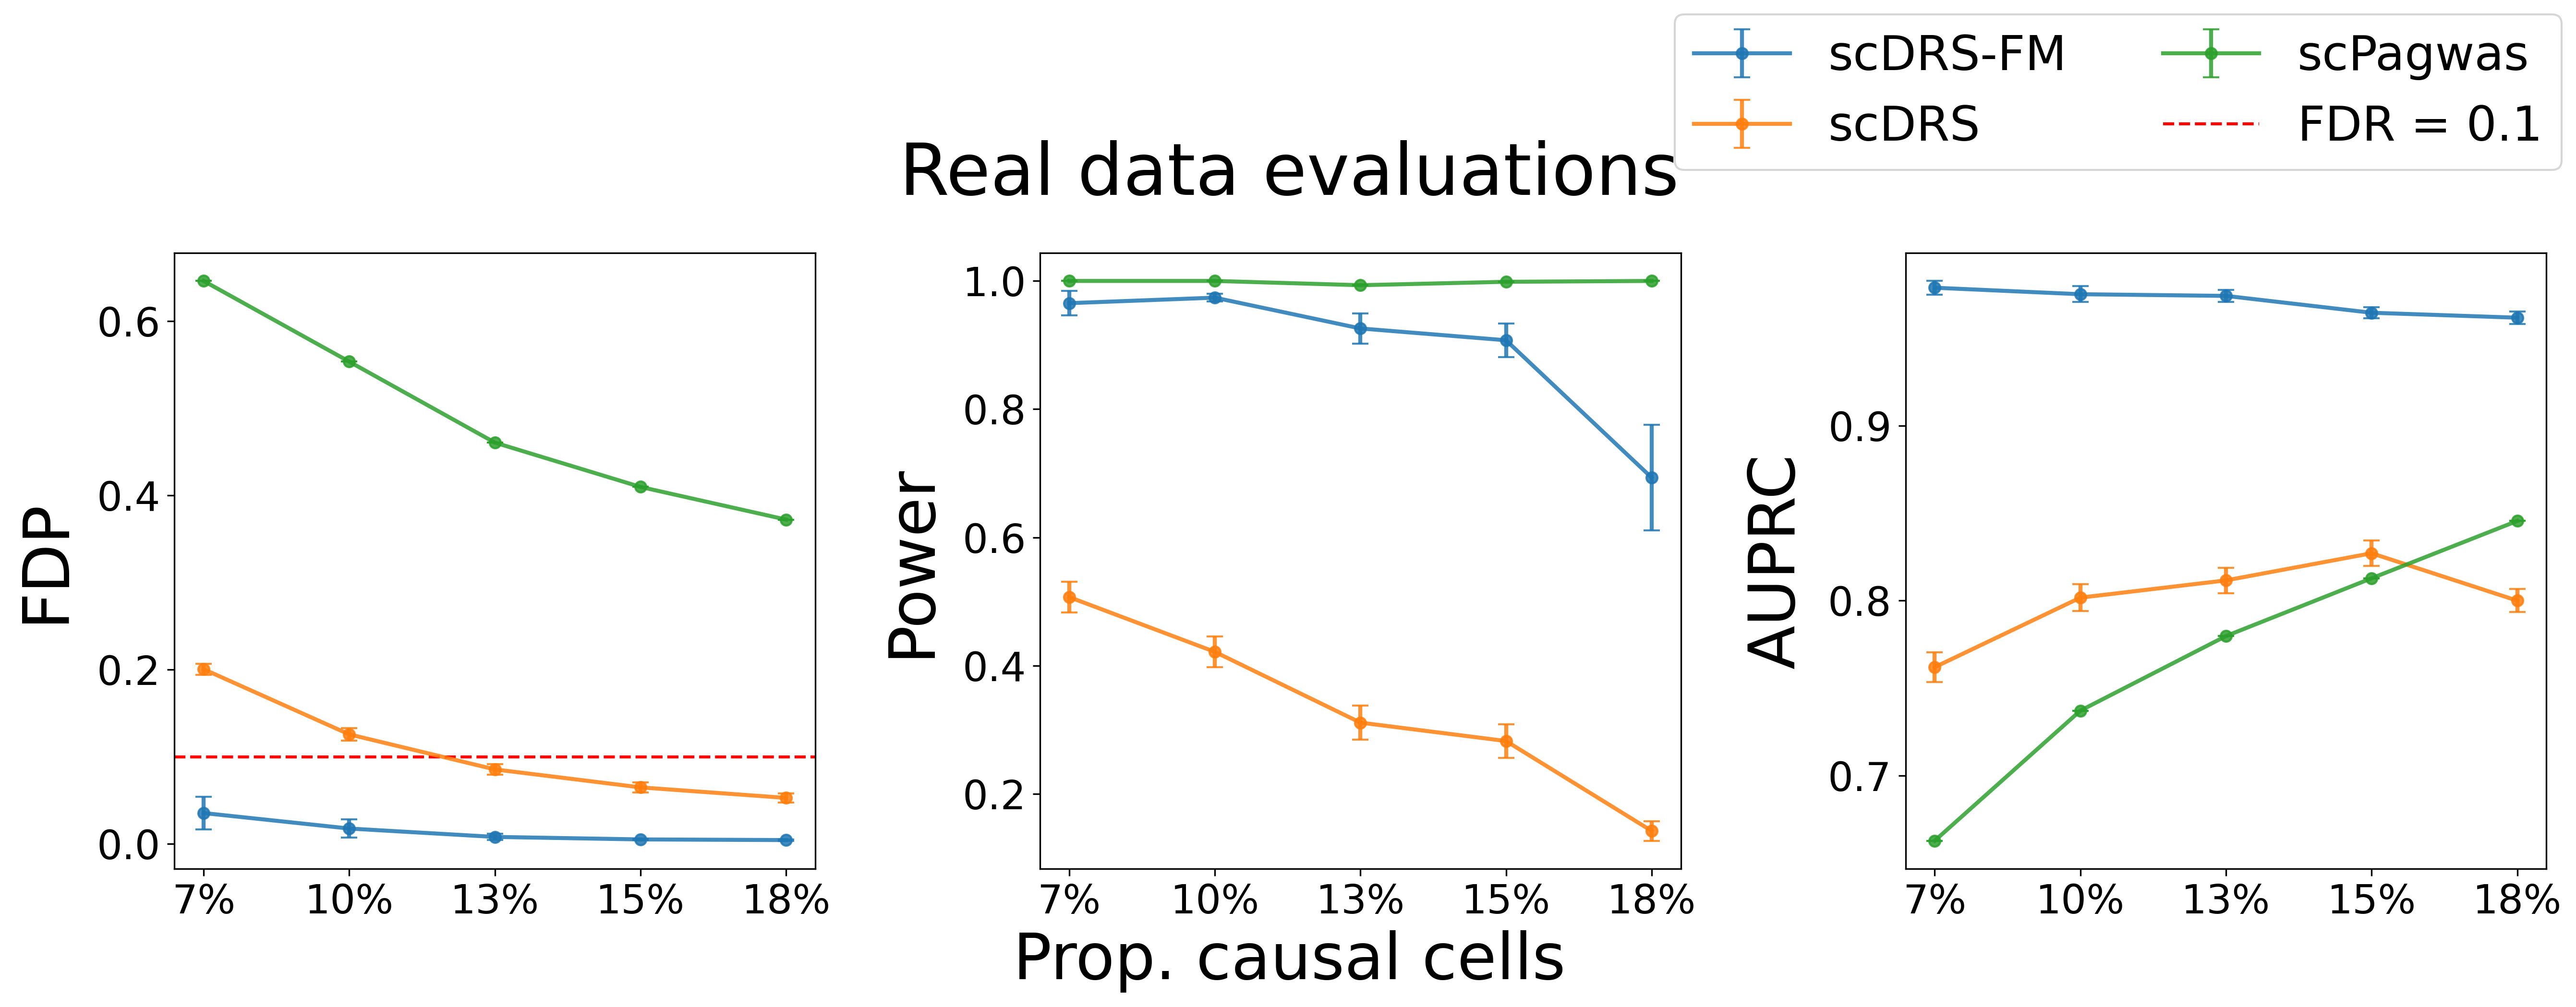

Saved figure to: /projects/zhanglab/users/alistair/scdrs_simpleby/Monocyte_Count_all_metrics_row.png


In [7]:
# -----------------------------------------------------------------------------
# Monocyte_Count_all_metrics_row.png
# -----------------------------------------------------------------------------
def mean_and_ci95(values: Iterable[float]) -> tuple[float, float]:
    finite = np.asarray(list(values), dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return np.nan, np.nan
    if finite.size == 1:
        return float(finite[0]), 0.0
    return (
        float(finite.mean()),
        float(1.96 * finite.std(ddof=1) / np.sqrt(finite.size)),
    )


method_order = ["scdrs_fm", "scdrs", "scpagwas"]
method_labels = {
    "scdrs_fm": "scDRS-FM",
    "scdrs": "scDRS",
    "scpagwas": "scPagwas",
}
metric_panels = [
    ("fdp", "FDP"),
    ("power", "Power"),
    ("auprc", "AUPRC"),
]

# Methods with no usable observations are omitted from all panels and legends.
active_methods = [
    method
    for method in method_order
    if any(
        len(benchmark_results["fdp"][method][prop]) > 0
        for prop in PROPS
    )
]
if not active_methods:
    print("No benchmark results were available to plot; CSV availability tables were still written.")

if not active_methods:
    # Nothing else in this cell should run when all result files are absent.
    pass
else:
    plot_params = {
        "figsize": (18, 8),
        "dpi": 300,
        "suptitle_fontsize": 36,
        "axis_label_fontsize": 32,
        "tick_label_fontsize": 20,
        "legend_fontsize": 24,
        "capsize": 4,
        "error_linewidth": 2.0,
        "suptitle_y": 0.84,
        "legend_y": 0.97,
        "tight_rect": (0, 0.07, 1, 0.84),
    }

    fig, axes = plt.subplots(
        1,
        3,
        figsize=plot_params["figsize"],
        dpi=plot_params["dpi"],
        sharex=True,
    )
    fig.suptitle(
        "Real data evaluations",
        fontsize=plot_params["suptitle_fontsize"],
        y=plot_params["suptitle_y"],
    )

    for ax, (metric_key, metric_label) in zip(axes, metric_panels):
        if metric_key == "fdp":
            ax.axhline(0.1, color="red", linestyle="--", linewidth=1.5, zorder=0)

        for method in active_methods:
            means, errors = zip(
                *[
                    mean_and_ci95(benchmark_results[metric_key][method][prop])
                    for prop in PROPS
                ]
            )
            ax.errorbar(
                range(len(PROPS)),
                means,
                yerr=errors,
                fmt="o-",
                linewidth=2.0,
                markersize=5.5,
                capsize=plot_params["capsize"],
                elinewidth=plot_params["error_linewidth"],
                alpha=0.85,
                label=method_labels[method],
            )

        ax.set_ylabel(
            metric_label,
            fontsize=plot_params["axis_label_fontsize"],
            labelpad=10,
        )
        ax.set_xticks(range(len(PROPS)))
        ax.set_xticklabels(
            [PROP_TICK_LABELS[prop] for prop in PROPS],
            fontsize=plot_params["tick_label_fontsize"],
        )
        ax.tick_params(axis="y", labelsize=plot_params["tick_label_fontsize"])
        ax.grid(False)

    fig.supxlabel(
        "Prop. causal cells",
        fontsize=plot_params["axis_label_fontsize"],
        y=0.1,
    )

    handles, legend_labels = axes[0].get_legend_handles_labels()
    handles.append(plt.Line2D([0], [0], color="red", linestyle="--", linewidth=1.5))
    legend_labels.append("FDR = 0.1")
    fig.legend(
        handles,
        legend_labels,
        fontsize=plot_params["legend_fontsize"],
        frameon=True,
        loc="upper right",
        bbox_to_anchor=(1.0, plot_params["legend_y"]),
        bbox_transform=fig.transFigure,
        ncol=2,
    )

    fig.tight_layout(rect=plot_params["tight_rect"])
    fig.savefig(BENCHMARK_OUTPUT, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved figure to: {BENCHMARK_OUTPUT.resolve()}")


## 3. Supplementary CSV manifest and archive

This cell inventories every generated CSV, records its columns and row count, and creates a single zip archive for manuscript transfer.


In [8]:
# -----------------------------------------------------------------------------
# Build a manifest and zip archive containing all supplementary CSV files
# -----------------------------------------------------------------------------
CSV_DESCRIPTIONS = {
    "ng_monocyte_big_h5ad_cell_population_counts_exact.csv": (
        "Exact BioClassification counts in the large reference h5ad."
    ),
    "ng_monocyte_big_h5ad_cell_type_counts_collapsed.csv": (
        "Collapsed manuscript-facing cell-type counts in the large reference h5ad."
    ),
    "ng_monocyte_benchmark_replicate_metrics_long.csv": (
        "One row per method, causal-cell proportion, and replicate with all metrics and counts."
    ),
    "ng_monocyte_benchmark_data_availability.csv": (
        "Input availability and error status for every expected method-proportion-replicate run."
    ),
    "ng_monocyte_simulated_sample_population_counts.csv": (
        "Exact cell-population counts for every simulated sample h5ad."
    ),
    "ng_monocyte_simulated_sample_summary.csv": (
        "Per-sample total cells, population count, causal-cell count, and causal fraction."
    ),
    "ng_monocyte_benchmark_summary_long.csv": (
        "Descriptive statistics by method, causal-cell proportion, and metric."
    ),
    "ng_monocyte_benchmark_summary_headline_metrics_wide.csv": (
        "Wide summary for empirical FDR, power, and AUPRC."
    ),
    "ng_monocyte_paired_replicate_differences_vs_scdrs_fm.csv": (
        "Paired replicate-level differences between scDRS-FM and each comparator."
    ),
    "ng_monocyte_paired_summary_vs_scdrs_fm.csv": (
        "Summary of paired scDRS-FM advantages and win proportions."
    ),
}

csv_paths = sorted(
    path
    for path in SUPPLEMENTARY_OUTPUT_DIR.glob("*.csv")
    if path.name != "ng_monocyte_supplementary_csv_manifest.csv"
)
manifest_rows = []
for path in csv_paths:
    try:
        header = pd.read_csv(path, nrows=0)
        columns = list(header.columns)
        # Counting lines is safe for these programmatically generated tables,
        # which do not contain embedded newline characters.
        with path.open("r", encoding="utf-8") as handle:
            row_count = max(sum(1 for _ in handle) - 1, 0)
    except Exception as exc:
        columns = []
        row_count = np.nan
        description = f"Could not inspect file: {type(exc).__name__}: {exc}"
    else:
        description = CSV_DESCRIPTIONS.get(
            path.name,
            "Per-replicate metric table generated by the monocyte benchmark.",
        )

    manifest_rows.append(
        {
            "filename": path.name,
            "description": description,
            "row_count": row_count,
            "column_count": len(columns),
            "columns": "; ".join(columns),
        }
    )

supplementary_manifest = pd.DataFrame(manifest_rows)
manifest_path = export_csv(
    supplementary_manifest,
    "ng_monocyte_supplementary_csv_manifest.csv",
)

all_csv_paths = sorted(SUPPLEMENTARY_OUTPUT_DIR.glob("*.csv"))
with zipfile.ZipFile(
    SUPPLEMENTARY_ZIP_OUTPUT,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for path in all_csv_paths:
        archive.write(path, arcname=path.name)

print(f"\nSupplementary CSV directory: {SUPPLEMENTARY_OUTPUT_DIR.resolve()}")
print(f"CSV files: {len(all_csv_paths)}")
for path in all_csv_paths:
    print(f"  - {path.name}")
print(f"Zip archive: {SUPPLEMENTARY_ZIP_OUTPUT.resolve()}")


Saved CSV: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte/ng_monocyte_supplementary_csv_manifest.csv

Supplementary CSV directory: /projects/zhanglab/users/alistair/scdrs_simpleby/nature_genetics_supplementary_monocyte
CSV files: 25
  - ng_monocyte_benchmark_data_availability.csv
  - ng_monocyte_benchmark_replicate_metrics_long.csv
  - ng_monocyte_benchmark_summary_headline_metrics_wide.csv
  - ng_monocyte_benchmark_summary_long.csv
  - ng_monocyte_big_h5ad_cell_population_counts_exact.csv
  - ng_monocyte_big_h5ad_cell_type_counts_collapsed.csv
  - ng_monocyte_paired_replicate_differences_vs_scdrs_fm.csv
  - ng_monocyte_paired_summary_vs_scdrs_fm.csv
  - ng_monocyte_replicate_auprc.csv
  - ng_monocyte_replicate_auprc_lift_over_prevalence.csv
  - ng_monocyte_replicate_auroc.csv
  - ng_monocyte_replicate_average_precision.csv
  - ng_monocyte_replicate_balanced_accuracy.csv
  - ng_monocyte_replicate_discovery_rate.csv
  - ng_monocyte_replicate_empi

## 4. Representative 2 × 2 UMAP


In [9]:
# -----------------------------------------------------------------------------
# Load the selected sample, calculate one shared UMAP, and attach p-values
# -----------------------------------------------------------------------------
UMAP_ADATA_PATH = sample_h5ad_path(PROP, REPLICATE)
FM_MARGINAL_PATH, FM_CONDITIONAL_PATH = scdrs_fm_paths(PROP, REPLICATE)
SCDRS_PATH = scdrs_score_path(PROP, REPLICATE)
SCPAGWAS_PATH = scpagwas_score_path(PROP, REPLICATE)

required_umap_inputs = {
    "sample AnnData": UMAP_ADATA_PATH,
    "scDRS-FM marginal scores": FM_MARGINAL_PATH,
    "scDRS-FM conditional scores": FM_CONDITIONAL_PATH,
    "scDRS scores": SCDRS_PATH,
}
missing_required = {
    name: path for name, path in required_umap_inputs.items() if not path.exists()
}
if missing_required:
    details = "\n".join(
        f"  - {name}: {path}" for name, path in missing_required.items()
    )
    raise FileNotFoundError(
        "Required UMAP inputs were not found. Run from the project root or "
        f"update PROJECT_ROOT:\n{details}"
    )

adata = sc.read_h5ad(UMAP_ADATA_PATH)
adata.obs_names = adata.obs_names.astype(str)
adata_umap = adata.copy()

sc.pp.filter_cells(adata_umap, min_genes=250)
sc.pp.filter_genes(adata_umap, min_cells=50)
sc.pp.normalize_total(adata_umap, target_sum=1e4)
sc.pp.log1p(adata_umap)
sc.pp.highly_variable_genes(
    adata_umap,
    subset=False,
    min_disp=0.5,
    min_mean=0.0125,
    max_mean=10,
    n_bins=20,
)

n_hvg = int(adata_umap.var["highly_variable"].sum())
max_components = min(50, adata_umap.n_obs - 1, n_hvg - 1)
if max_components < 2:
    raise ValueError(
        "Too few cells/highly variable genes for PCA: "
        f"n_obs={adata_umap.n_obs}, n_hvg={n_hvg}."
    )

sc.pp.scale(adata_umap, max_value=10, zero_center=False)
sc.pp.pca(
    adata_umap,
    n_comps=max_components,
    use_highly_variable=True,
    svd_solver="arpack",
    random_state=RANDOM_SEED,
)
sc.pp.neighbors(
    adata_umap,
    n_neighbors=min(15, adata_umap.n_obs - 1),
    n_pcs=min(40, max_components),
    random_state=RANDOM_SEED,
)
sc.tl.umap(adata_umap, random_state=RANDOM_SEED)

if BIOCLASSIFICATION_KEY not in adata_umap.obs:
    raise KeyError(f"AnnData is missing obs[{BIOCLASSIFICATION_KEY!r}].")

bio = adata_umap.obs[BIOCLASSIFICATION_KEY].astype(str)
cell_type = bio.map(BIO_TO_CELLTYPE).fillna(bio)
extra_types = [
    value for value in pd.unique(cell_type)
    if value not in PREFERRED_CELL_TYPE_ORDER
]
adata_umap.obs["cell_type"] = pd.Categorical(
    cell_type,
    categories=PREFERRED_CELL_TYPE_ORDER + extra_types,
    ordered=True,
)

fm_result = load_scdrs_fm_result(adata_umap.obs_names, PROP, REPLICATE)
scdrs_result = load_scdrs_result(adata_umap.obs_names, PROP, REPLICATE)
if fm_result is None or scdrs_result is None:
    raise FileNotFoundError("Required scDRS-FM or scDRS result files were not loaded.")

umap_pvalues = {
    "scDRS-FM": fm_result.pvalues,
    "scDRS": scdrs_result.pvalues,
}

# scPagwas is optional and requires both the original h5ad and this score file.
scpagwas_umap_reason = None
if not SCPAGWAS_REFERENCE_H5AD.exists():
    scpagwas_umap_reason = "original h5ad not found"
elif not SCPAGWAS_PATH.exists():
    scpagwas_umap_reason = "score file not found"
else:
    reference_obs = load_optional_scpagwas_reference()
    if reference_obs is None:
        scpagwas_umap_reason = "original h5ad could not be read"
    else:
        scpagwas_result = load_scpagwas_result(reference_obs, PROP, REPLICATE)
        if scpagwas_result is None:
            scpagwas_umap_reason = "score IDs did not match the original h5ad"
        else:
            try:
                umap_pvalues["scPagwas"] = align_pvalues(
                    scpagwas_result.pvalues,
                    adata_umap.obs_names,
                    source="scPagwas UMAP",
                )
            except ValueError as exc:
                scpagwas_umap_reason = str(exc)

if scpagwas_umap_reason is not None:
    warnings.warn(
        f"scPagwas UMAP panel skipped: {scpagwas_umap_reason}.",
        stacklevel=2,
    )

for method, pvalues in umap_pvalues.items():
    key = method.lower().replace("-", "_").replace(" ", "_")
    adata_umap.obs[f"{key}_log10p"] = -np.log10(
        pvalues.reindex(adata_umap.obs_names).to_numpy(dtype=float)
    )

print(f"Loaded {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(
    f"UMAP uses {adata_umap.n_obs:,} cells × "
    f"{adata_umap.n_vars:,} filtered genes"
)


/home/aturcan/miniconda3/envs/scdrs6/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


Loaded 5,092 cells × 11,371 genes
UMAP uses 5,092 cells × 10,457 filtered genes


In [10]:
# -----------------------------------------------------------------------------
# UMAP plotting helpers
# -----------------------------------------------------------------------------
RDBU = plt.get_cmap("RdBu_r")


def finish_umap_axis(ax: plt.Axes) -> None:
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_aspect("equal", adjustable="datalim")


def plot_cell_types(
    ax: plt.Axes,
    xy: np.ndarray,
    groups: pd.Series,
    *,
    point_size: float,
) -> None:
    groups = groups.astype("category")
    present = [category for category in groups.cat.categories if (groups == category).any()]

    categorical_colors = (
        list(plt.get_cmap("tab20").colors)
        + list(plt.get_cmap("tab20b").colors)
        + list(plt.get_cmap("tab20c").colors)
    )
    palette = {
        category: categorical_colors[index % len(categorical_colors)]
        for index, category in enumerate(present)
    }

    # Draw large groups first and rare groups last so small populations remain visible.
    counts = groups.value_counts().sort_values(ascending=False)
    for category in counts.index:
        if category not in palette or counts[category] == 0:
            continue
        mask = (groups == category).to_numpy()
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=point_size,
            c=[palette[category]],
            linewidths=0,
            alpha=0.90,
            rasterized=True,
        )

    for category in present:
        mask = (groups == category).to_numpy()
        center = np.nanmedian(xy[mask], axis=0)
        label = ax.text(
            center[0],
            center[1],
            str(category),
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color="black",
            zorder=10,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.82,
            },
        )
        label.set_path_effects(
            [path_effects.withStroke(linewidth=2.0, foreground="white")]
        )

    ax.set_title("Cell types", fontsize=26, fontweight="bold", pad=16)
    finish_umap_axis(ax)


def plot_significance(
    ax: plt.Axes,
    xy: np.ndarray,
    values: np.ndarray,
    *,
    title: str,
    norm: Normalize,
    point_size: float,
) -> None:
    values = np.asarray(values, dtype=float)
    order = np.argsort(np.nan_to_num(values, nan=-np.inf), kind="mergesort")
    ax.scatter(
        xy[order, 0],
        xy[order, 1],
        c=values[order],
        cmap=RDBU,
        norm=norm,
        s=point_size,
        linewidths=0,
        alpha=0.92,
        rasterized=True,
    )
    ax.set_title(title, fontsize=26, fontweight="bold", pad=16)
    finish_umap_axis(ax)


def plot_skipped_scpagwas_panel(ax: plt.Axes, reason: str) -> None:
    ax.text(
        0.5,
        0.5,
        "scPagwas skipped\n" + reason,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=18,
    )
    ax.set_title("scPagwas", fontsize=26, fontweight="bold", pad=16)
    ax.set_axis_off()


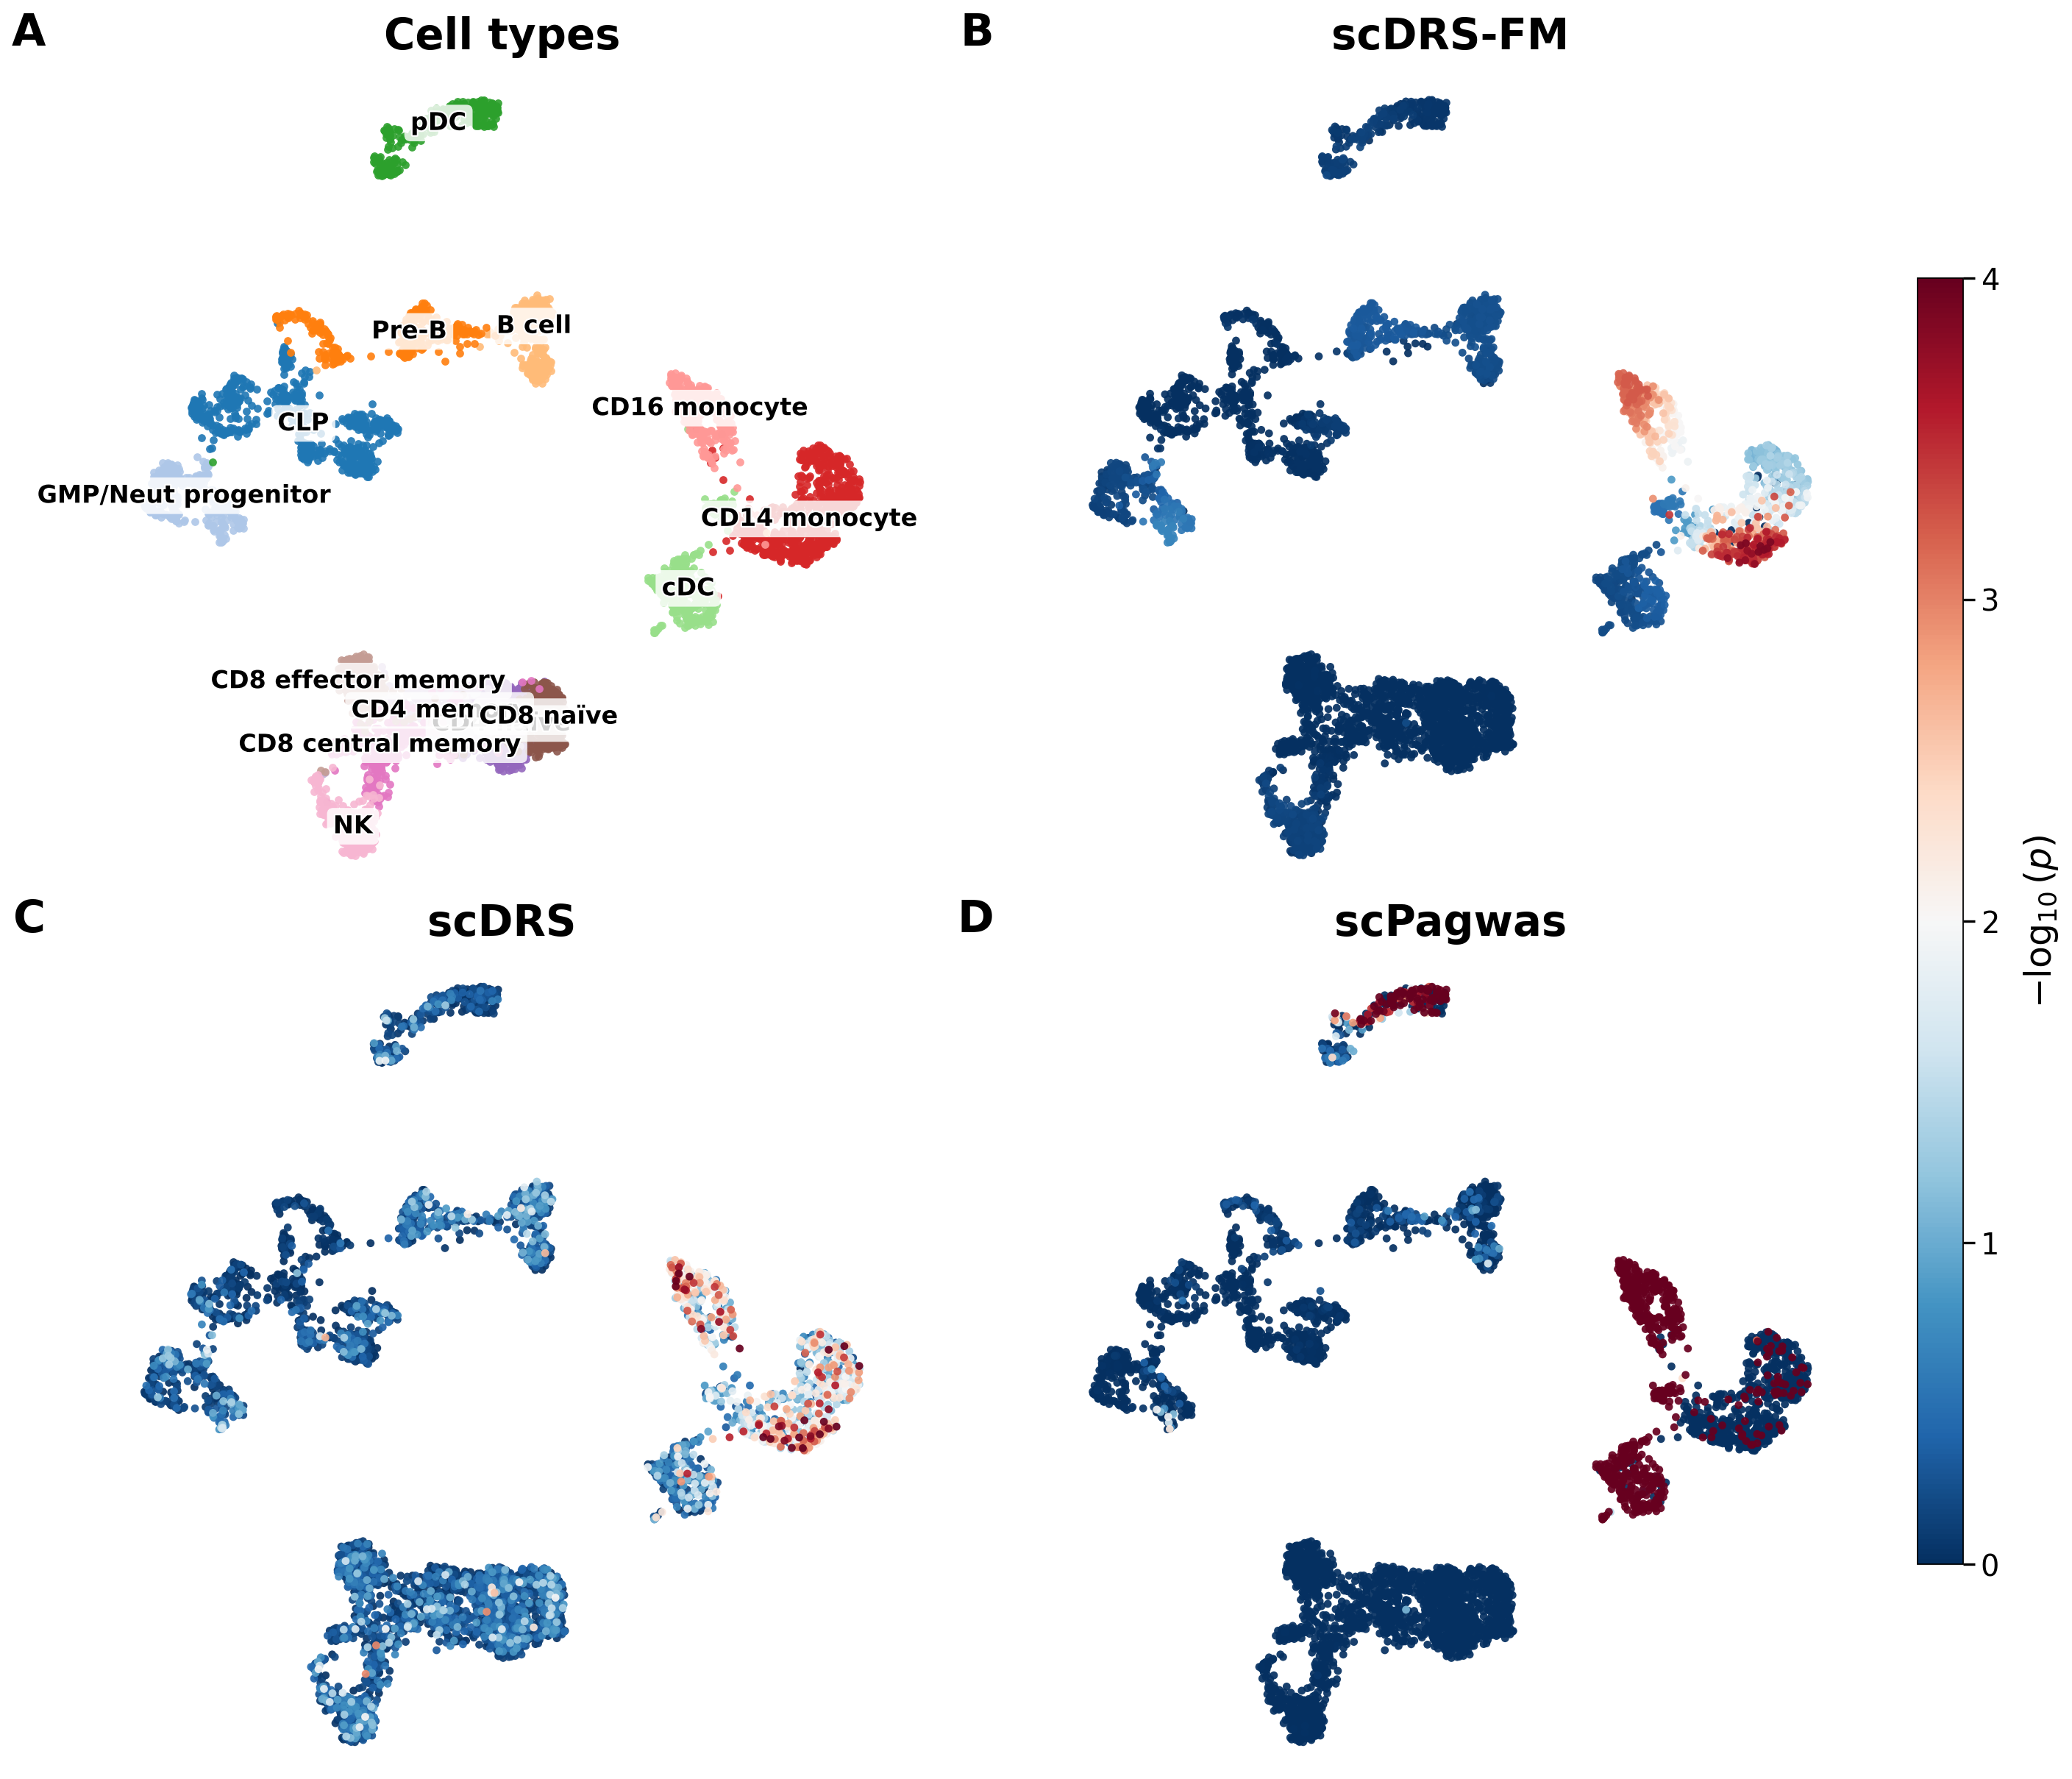

Saved figure to: /projects/zhanglab/users/alistair/scdrs_simpleby/umap_300_300_rep1_2x2.png
Shared color range: 0 to 4 on the -log10(p) scale


In [11]:
# -----------------------------------------------------------------------------
# umap_{PROP}_rep{REPLICATE}_2x2.png
# -----------------------------------------------------------------------------
xy = np.asarray(adata_umap.obsm["X_umap"][:, :2])
logp = {
    method: -np.log10(pvalues.reindex(adata_umap.obs_names).to_numpy(dtype=float))
    for method, pvalues in umap_pvalues.items()
}
finite_logp = np.concatenate(
    [values[np.isfinite(values)] for values in logp.values()]
)
if finite_logp.size == 0:
    raise ValueError("No finite -log10(p) values were loaded.")

norm = Normalize(vmin=0.0, vmax=COLOR_VMAX, clip=True)
point_size = float(np.clip(120_000 / adata_umap.n_obs, 10.0, 32.0))

fig, axes = plt.subplots(
    2,
    2,
    figsize=(17.5, 15.0),
    dpi=160,
    constrained_layout=True,
)

plot_cell_types(
    axes[0, 0],
    xy,
    adata_umap.obs["cell_type"],
    point_size=point_size,
)
plot_significance(
    axes[0, 1],
    xy,
    logp["scDRS-FM"],
    title="scDRS-FM",
    norm=norm,
    point_size=point_size,
)
plot_significance(
    axes[1, 0],
    xy,
    logp["scDRS"],
    title="scDRS",
    norm=norm,
    point_size=point_size,
)

if "scPagwas" in logp:
    plot_significance(
        axes[1, 1],
        xy,
        logp["scPagwas"],
        title="scPagwas",
        norm=norm,
        point_size=point_size,
    )
else:
    plot_skipped_scpagwas_panel(
        axes[1, 1],
        scpagwas_umap_reason or "required inputs were unavailable",
    )

for ax, letter in zip(axes.ravel(), "ABCD"):
    ax.text(
        -0.025,
        1.025,
        letter,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=27,
        fontweight="bold",
    )

color_mappable = ScalarMappable(norm=norm, cmap=RDBU)
color_mappable.set_array([])
colorbar = fig.colorbar(
    color_mappable,
    ax=axes.ravel().tolist(),
    location="right",
    shrink=0.76,
    pad=0.018,
    aspect=28,
    ticks=np.arange(0, COLOR_VMAX + 1),
)
colorbar.set_label(r"$-\log_{10}(p)$", fontsize=22, labelpad=14)
colorbar.ax.tick_params(labelsize=18, width=1.5, length=7)

fig.savefig(
    UMAP_OUTPUT,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()
print(f"Saved figure to: {UMAP_OUTPUT.resolve()}")
print(f"Shared color range: 0 to {COLOR_VMAX:g} on the -log10(p) scale")
